<a href="https://www.kaggle.com/code/shravankumarpandey/cricket-stats-calculation-using-langgraph?scriptVersionId=335377063" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Cricket Stats Calculation using LangGraph

In [6]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

class BatsamanState(TypedDict):
    runs:int
    balls:int
    four:int
    six:int

    strike_rate:float
    balls_per_boundary:int
    boundary_percentage:float
    summary:str

def strike_rate_node(state:BatsamanState)->BatsamanState:
    strike_rate=state["runs"]/state["balls"]*100
    return {"strike_rate":strike_rate}

def ball_per_boundary_node(state:BatsamanState)->BatsamanState:
    balls_per_boundary=state["balls"]/(state["four"]+state["six"])
    return {"balls_per_boundary":balls_per_boundary}

def boundary_percentage_node(state:BatsamanState)->BatsamanState:
    boundary_percentage=(state["four"]+state["six"])/state["balls"]*100
    return {"boundary_percentage":boundary_percentage}

def summary_node(state:BatsamanState)->BatsamanState:
    summary=f"""
    Runs:{state['runs']}  
    Balls:{state['balls']}
    Four:{state['four']}
    Six:{state['six']}
    Strike_Rate:{state['strike_rate']}
    Balls_per_Boundary:{state['balls_per_boundary']}
    Boundary_Percentage:{state['boundary_percentage']}%
"""

    
    return {"summary":summary}

graph=StateGraph(BatsamanState)

graph.add_node("strike_rate_node",strike_rate_node)
graph.add_node("ball_per_boundary_node",ball_per_boundary_node)
graph.add_node("boundary_percentage_node",boundary_percentage_node)
graph.add_node("summary_node",summary_node)

graph.add_edge(START,"strike_rate_node")
graph.add_edge(START,"ball_per_boundary_node")
graph.add_edge(START,"boundary_percentage_node")

graph.add_edge("strike_rate_node","summary_node")
graph.add_edge("ball_per_boundary_node","summary_node")
graph.add_edge("boundary_percentage_node","summary_node")
graph.add_edge("summary_node",END)

workflow=graph.compile()

initial_state={
    "runs":100,
    "balls":50,
    "four":6,
    "six":4
}

result=workflow.invoke(initial_state)
print(result["summary"])



    Runs:100  
    Balls:50
    Four:6
    Six:4
    Strike_Rate:200.0
    Balls_per_Boundary:5.0
    Boundary_Percentage:20.0%



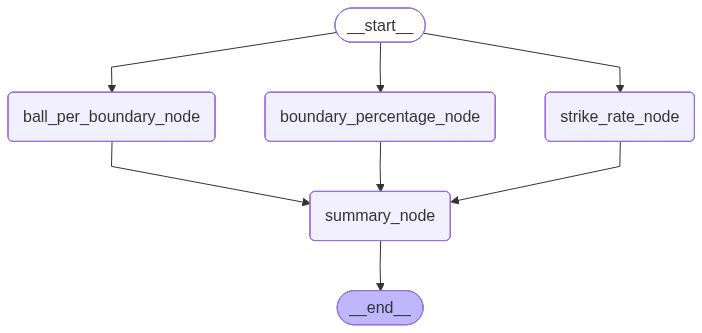

In [5]:
workflow